****Imports****

In [24]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

print("Libraries imported")

Libraries imported


**Dataset Path**

In [5]:
for root, dirs, files in os.walk("/kaggle/input"):
    if "NORMAL" in dirs and "PNEUMONIA" in dirs:
        print(root)

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train


In [6]:
DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
print(os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH))

True
['PNEUMONIA', 'NORMAL']


**Dataset Loader**

In [7]:
def load_dataset(sample_size):

    normal_path = os.path.join(DATASET_PATH, "NORMAL")
    pneumonia_path = os.path.join(DATASET_PATH, "PNEUMONIA")

    per_class = sample_size // 2

    normal_files = random.sample(
        os.listdir(normal_path),
        per_class
    )

    pneumonia_files = random.sample(
        os.listdir(pneumonia_path),
        per_class
    )

    images = []
    labels = []

    for file in normal_files:

        img = Image.open(
            os.path.join(normal_path, file)
        )

        img = img.convert("RGB")
        img = img.resize((224, 224))

        images.append(np.array(img))
        labels.append(0)

    for file in pneumonia_files:

        img = Image.open(
            os.path.join(pneumonia_path, file)
        )

        img = img.convert("RGB")
        img = img.resize((224, 224))

        images.append(np.array(img))
        labels.append(1)

    X = np.array(images) / 255.0
    y = np.array(labels)

    return X, y

**Densenet121 Mode**

In [8]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D

def create_densenet121():

    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    predictions = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=predictions
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

**Experiment Loop**

In [9]:
dataset_sizes = [200, 500, 1000]

results = []

**Training**

In [10]:
for size in dataset_sizes:

    print(f"\nTraining Densenet121 with {size} images")

    X, y = load_dataset(size)

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model = create_densenet121()

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=16,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    val_loss, val_acc = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    results.append({
        "Dataset Size": size,
        "Accuracy": round(val_acc * 100, 2),
        "Loss": round(val_loss, 4),
        "Training Time": round(training_time, 2)
    })

    print(
        f"Accuracy: {val_acc:.4f} | "
        f"Loss: {val_loss:.4f} | "
        f"Time: {training_time:.2f} sec"
    )


Training Densenet121 with 200 images


2026-06-20 11:17:59.714807: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4938 - loss: 0.8176 - val_accuracy: 0.9250 - val_loss: 0.4775
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8562 - loss: 0.3672 - val_accuracy: 0.9000 - val_loss: 0.3083
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9250 - loss: 0.2474 - val_accuracy: 0.8750 - val_loss: 0.2490
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9312 - loss: 0.2043 - val_accuracy: 0.9000 - val_loss: 0.2205
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9375 - loss: 0.1683 - val_accuracy: 0.8750 - val_loss: 0.2354
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9500 - loss: 0.1573 - val_accuracy: 0.8500 - val_loss: 0.2973
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9688 - loss: 0.1268 - val_accuracy: 0.9000 - val_loss: 0.1976
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.975

**Results Table**

In [11]:
densenet121_results_df = pd.DataFrame(results)

densenet121_results_df

,Dataset Size,Accuracy,Loss,Training Time
0,200,90.0,0.1705,180.13
1,500,96.0,0.0949,403.87
2,1000,95.0,0.1207,806.83


**Save CSV**

In [12]:
densenet121_results_df.to_csv(
    "densenet121_results.csv",
    index=False
)

**Accuracy Graph**

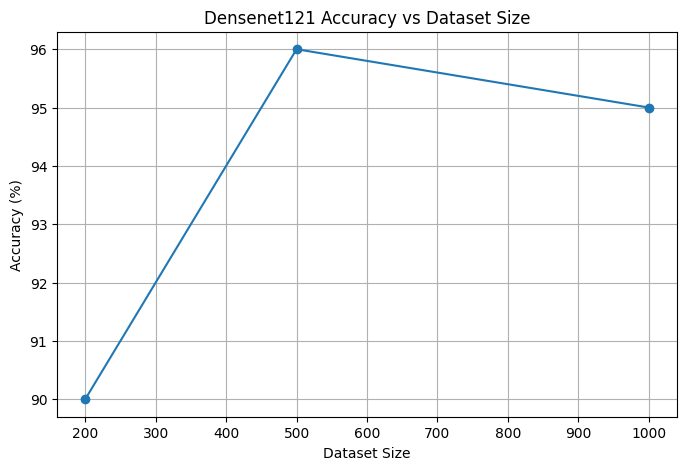

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    densenet121_results_df["Dataset Size"],
    densenet121_results_df["Accuracy"],
    marker="o"
)

plt.title("Densenet121 Accuracy vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

**Loss Graph**

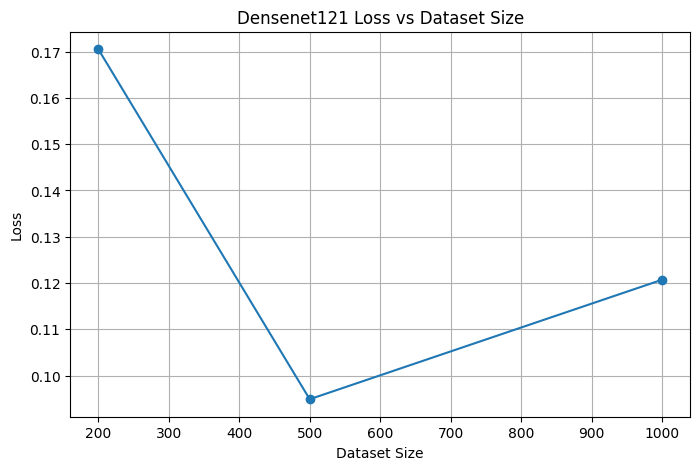

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    densenet121_results_df["Dataset Size"],
    densenet121_results_df["Loss"],
    marker="o"
)

plt.title("Densenet121 Loss vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

**Time Training graph**

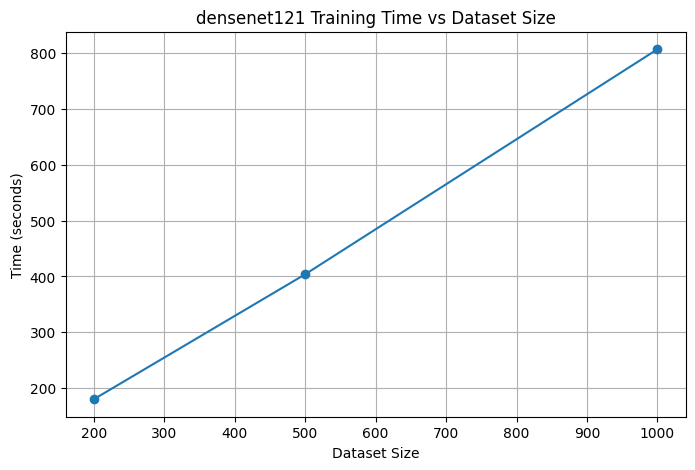

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    densenet121_results_df["Dataset Size"],
    densenet121_results_df["Training Time"],
    marker="o"
)

plt.title("densenet121 Training Time vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")

plt.grid(True)

plt.show()